# Aggregated Input Table (48h)

> Build a 48-hour dispatch input table from solar, price, and load sources at 15-minute UTC resolution.

## Workflow
1. Load imports and helper modules.
2. Build or reuse a 48h merged table (same-day cache policy, 15-minute minimum update interval).
3. Validate shape and timestamp continuity.
4. Rename/export the final schema to `data/aggregated_table.csv`.
5. Plot the three core signals with source labels.

In [33]:
# Standard library imports
import json
from pathlib import Path

# Data and plotting imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Project forecast utilities (load kept as-is / WIP)
from files.load import get_daily_load_forecast
from files.prices import get_daily_prices
from files.solar import get_daily_solar_kwh


## Build Or Reuse 48h Source Data

This section creates a merged 48h dataset for solar, prices, and load.

- Cache reuse is allowed only when the requested `date` is the same as the last run.
- Updates are throttled to at most one refresh every 15 minutes.
- If price values are missing in future intervals, it fills from the latest available day profile.
- Solar and load are prepared as two-day (48h) concatenations.

In [34]:
# Build/update a 48h aggregated input table.
# Refresh policy:
# - Reuse cache only for the same requested day.
# - Never refresh more frequently than every 15 minutes for that day.

date = "2026-03-20"  # start day (UTC)
UPDATE_EVERY = pd.Timedelta(minutes=15)
DEFAULT_PRICE_CENT_KWH = 8.0
DEFAULT_LOAD_KWH_15MIN = 0.0
OUTPUT_PATH = Path("data/aggregated_table.csv")
STATE_PATH = Path("data/.aggreg_table_state.json")

START_DAY = pd.Timestamp(date, tz="UTC").date()
NOW_UTC = pd.Timestamp.now(tz="UTC")


def _next_day(day_obj):
    return (pd.Timestamp(day_obj, tz="UTC") + pd.Timedelta(days=1)).date()


def _day_index(day_obj):
    return pd.date_range(start=pd.Timestamp(day_obj, tz="UTC"), periods=96, freq="15min")


def _fetch_48h_solar(start_day):
    days = [start_day, _next_day(start_day)]
    frames = [get_daily_solar_kwh(day) for day in days]
    return pd.concat(frames, ignore_index=True)


def _load_cached_latest_price_profile():
    if not OUTPUT_PATH.exists():
        return None, None

    try:
        cached = pd.read_csv(OUTPUT_PATH)
    except Exception:
        return None, None

    required_cols = {"utc_timestamp", "energy_price_buy_cent_kwh"}
    if not required_cols.issubset(cached.columns):
        return None, None

    cached["utc_timestamp"] = pd.to_datetime(cached["utc_timestamp"], utc=True, errors="coerce")
    cached["energy_price_buy_cent_kwh"] = pd.to_numeric(cached["energy_price_buy_cent_kwh"], errors="coerce")
    cached = cached.dropna(subset=["utc_timestamp", "energy_price_buy_cent_kwh"]).sort_values("utc_timestamp")

    if cached.empty:
        return None, None

    cached["day"] = cached["utc_timestamp"].dt.floor("D")
    latest_day = cached["day"].max()
    latest_day_df = cached[cached["day"] == latest_day].sort_values("utc_timestamp").reset_index(drop=True)

    if len(latest_day_df) < 96:
        return None, None

    latest_day_df = latest_day_df.iloc[:96].copy()
    profile = pd.DataFrame({
        "price_cent_kwh": latest_day_df["energy_price_buy_cent_kwh"].values,
    })
    profile["price_eur_mwh"] = profile["price_cent_kwh"] * 10.0
    profile = profile[["price_eur_mwh", "price_cent_kwh"]].ffill().bfill()

    if profile["price_cent_kwh"].isna().all():
        return None, None

    return profile.reset_index(drop=True), latest_day.date()


def _find_latest_price_profile(start_day, max_lookback_days=3):
    cached_profile, cached_day = _load_cached_latest_price_profile()
    if cached_profile is not None:
        return cached_profile, cached_day

    for offset in range(max_lookback_days + 1):
        candidate_day = (pd.Timestamp(start_day, tz="UTC") - pd.Timedelta(days=offset)).date()

        try:
            candidate = get_daily_prices(candidate_day).copy()
        except Exception:
            continue

        candidate["time"] = pd.to_datetime(candidate["time"], utc=True, errors="coerce")
        candidate["price_cent_kwh"] = pd.to_numeric(candidate["price_cent_kwh"], errors="coerce")
        candidate["price_eur_mwh"] = pd.to_numeric(candidate["price_eur_mwh"], errors="coerce")
        candidate = candidate.dropna(subset=["time"]).sort_values("time").reset_index(drop=True)

        if len(candidate) == 96 and candidate["price_cent_kwh"].notna().any():
            profile = candidate[["price_eur_mwh", "price_cent_kwh"]].ffill().bfill().reset_index(drop=True)
            return profile, candidate_day

    flat_profile = pd.DataFrame({
        "price_eur_mwh": np.full(96, DEFAULT_PRICE_CENT_KWH * 10.0),
        "price_cent_kwh": np.full(96, DEFAULT_PRICE_CENT_KWH),
    })
    return flat_profile, "flat_default_price"


def _build_price_day_with_fallback(target_day, fallback_profile, fallback_day):
    try:
        day_prices = get_daily_prices(target_day).copy()
    except Exception:
        day_prices = pd.DataFrame({"time": _day_index(target_day)})

    for col in ["time", "price_eur_mwh", "price_cent_kwh", "source"]:
        if col not in day_prices.columns:
            day_prices[col] = np.nan

    day_prices["time"] = pd.to_datetime(day_prices["time"], utc=True, errors="coerce")
    day_prices["price_eur_mwh"] = pd.to_numeric(day_prices["price_eur_mwh"], errors="coerce")
    day_prices["price_cent_kwh"] = pd.to_numeric(day_prices["price_cent_kwh"], errors="coerce")

    base = pd.DataFrame({"time": _day_index(target_day)})
    day_prices = base.merge(
        day_prices[["time", "price_eur_mwh", "price_cent_kwh", "source"]],
        on="time",
        how="left",
    ).sort_values("time").reset_index(drop=True)

    missing_mask = day_prices["price_cent_kwh"].isna()
    if missing_mask.any():
        day_prices.loc[missing_mask, "price_eur_mwh"] = fallback_profile.loc[missing_mask, "price_eur_mwh"].values
        day_prices.loc[missing_mask, "price_cent_kwh"] = fallback_profile.loc[missing_mask, "price_cent_kwh"].values
        day_prices.loc[missing_mask, "source"] = f"fallback_latest_day_profile_{fallback_day}"

    day_prices["source"] = day_prices["source"].fillna(f"fallback_latest_day_profile_{fallback_day}")
    return day_prices


def _fetch_48h_prices(start_day):
    fallback_profile, fallback_day = _find_latest_price_profile(start_day)

    days = [start_day, _next_day(start_day)]
    frames = [
        _build_price_day_with_fallback(day, fallback_profile=fallback_profile, fallback_day=fallback_day)
        for day in days
    ]
    return pd.concat(frames, ignore_index=True)


def _load_cached_latest_load_profile():
    if not OUTPUT_PATH.exists():
        return None, None, None

    try:
        cached = pd.read_csv(OUTPUT_PATH)
    except Exception:
        return None, None, None

    required_cols = {"utc_timestamp", "household_load_kwh"}
    if not required_cols.issubset(cached.columns):
        return None, None, None

    cached["utc_timestamp"] = pd.to_datetime(cached["utc_timestamp"], utc=True, errors="coerce")
    cached["household_load_kwh"] = pd.to_numeric(cached["household_load_kwh"], errors="coerce")
    cached = cached.dropna(subset=["utc_timestamp", "household_load_kwh"]).sort_values("utc_timestamp")

    if cached.empty:
        return None, None, None

    cached["day"] = cached["utc_timestamp"].dt.floor("D")
    latest_day = cached["day"].max()
    latest_day_df = cached[cached["day"] == latest_day].sort_values("utc_timestamp").reset_index(drop=True)

    if len(latest_day_df) < 96:
        return None, None, None

    latest_day_df = latest_day_df.iloc[:96].copy()
    profile = pd.DataFrame({
        "predicted_kwh": latest_day_df["household_load_kwh"].values,
    })
    profile["predicted_kw"] = profile["predicted_kwh"] * 4.0
    profile = profile[["predicted_kwh", "predicted_kw"]].ffill().bfill()

    if profile["predicted_kwh"].isna().all():
        return None, None, None

    household_name = "residential1"
    if "household" in latest_day_df.columns and latest_day_df["household"].notna().any():
        household_name = latest_day_df["household"].dropna().iloc[0]

    return profile.reset_index(drop=True), latest_day.date(), household_name


def _find_latest_load_profile(start_day, max_lookback_days=7):
    cached_profile, cached_day, cached_household = _load_cached_latest_load_profile()
    if cached_profile is not None:
        return cached_profile, cached_day, cached_household

    for offset in range(max_lookback_days + 1):
        candidate_day = (pd.Timestamp(start_day, tz="UTC") - pd.Timedelta(days=offset)).date()
        try:
            candidate = get_daily_load_forecast(candidate_day).copy()
        except Exception:
            continue

        if "predicted_kwh" not in candidate.columns:
            continue

        candidate["time"] = pd.to_datetime(candidate["time"], utc=True, errors="coerce")
        candidate["predicted_kwh"] = pd.to_numeric(candidate["predicted_kwh"], errors="coerce")
        candidate = candidate.dropna(subset=["time"]).sort_values("time").reset_index(drop=True)

        if len(candidate) == 96 and candidate["predicted_kwh"].notna().any():
            profile = pd.DataFrame({
                "predicted_kwh": candidate["predicted_kwh"].values,
                "predicted_kw": pd.to_numeric(candidate.get("predicted_kw", candidate["predicted_kwh"] * 4.0), errors="coerce"),
            }).ffill().bfill()

            household_name = "residential1"
            if "household" in candidate.columns and candidate["household"].notna().any():
                household_name = candidate["household"].dropna().iloc[0]

            return profile.reset_index(drop=True), candidate_day, household_name

    flat_profile = pd.DataFrame({
        "predicted_kwh": np.full(96, DEFAULT_LOAD_KWH_15MIN),
        "predicted_kw": np.full(96, DEFAULT_LOAD_KWH_15MIN * 4.0),
    })
    return flat_profile, "flat_default_load", "residential1"


def _build_load_day_with_fallback(target_day, fallback_profile, fallback_day, fallback_household):
    try:
        day_load = get_daily_load_forecast(target_day).copy()
    except Exception:
        day_load = pd.DataFrame({"time": _day_index(target_day)})

    for col in ["time", "predicted_kwh", "predicted_kw", "household", "source"]:
        if col not in day_load.columns:
            day_load[col] = np.nan

    day_load["time"] = pd.to_datetime(day_load["time"], utc=True, errors="coerce")
    day_load["predicted_kwh"] = pd.to_numeric(day_load["predicted_kwh"], errors="coerce")
    day_load["predicted_kw"] = pd.to_numeric(day_load["predicted_kw"], errors="coerce")

    base = pd.DataFrame({"time": _day_index(target_day)})
    day_load = base.merge(
        day_load[["time", "predicted_kwh", "predicted_kw", "household", "source"]],
        on="time",
        how="left",
    ).sort_values("time").reset_index(drop=True)

    missing_mask = day_load["predicted_kwh"].isna()
    if missing_mask.any():
        day_load.loc[missing_mask, "predicted_kwh"] = fallback_profile.loc[missing_mask, "predicted_kwh"].values
        day_load.loc[missing_mask, "predicted_kw"] = fallback_profile.loc[missing_mask, "predicted_kw"].values
        day_load.loc[missing_mask, "source"] = f"fallback_latest_day_profile_{fallback_day}"

    day_load["predicted_kw"] = day_load["predicted_kw"].fillna(day_load["predicted_kwh"] * 4.0)
    day_load["household"] = day_load["household"].fillna(fallback_household)
    day_load["source"] = day_load["source"].fillna(f"fallback_latest_day_profile_{fallback_day}")

    return day_load


def _fetch_48h_load(start_day):
    fallback_profile, fallback_day, fallback_household = _find_latest_load_profile(start_day)

    days = [start_day, _next_day(start_day)]
    frames = [
        _build_load_day_with_fallback(
            day,
            fallback_profile=fallback_profile,
            fallback_day=fallback_day,
            fallback_household=fallback_household,
        )
        for day in days
    ]
    return pd.concat(frames, ignore_index=True)


def _build_48h_df(start_day):
    solar_48h = _fetch_48h_solar(start_day)
    prices_48h = _fetch_48h_prices(start_day)
    load_48h = _fetch_48h_load(start_day)

    merged = pd.merge(solar_48h, prices_48h, on="time", how="inner")
    merged = pd.merge(merged, load_48h, on="time", how="inner")

    merged["time"] = pd.to_datetime(merged["time"], utc=True, errors="coerce")
    merged = merged.dropna(subset=["time"]).sort_values("time").reset_index(drop=True)

    expected_rows = 48 * 4
    if len(merged) != expected_rows:
        raise ValueError(f"Expected {expected_rows} rows (48h at 15-min), got {len(merged)}")

    return merged


def _should_refresh(now_utc):
    if not OUTPUT_PATH.exists():
        return True, "aggregated_table.csv not found"
    if not STATE_PATH.exists():
        return True, "state file not found"

    try:
        state = json.loads(STATE_PATH.read_text(encoding="utf-8"))
        last_update = pd.to_datetime(state["last_update_utc"], utc=True)
        last_start_day = pd.to_datetime(state.get("start_day_utc"), utc=True).date() if state.get("start_day_utc") else None
    except Exception:
        return True, "state file invalid"

    # If a different day is requested, always refresh (ignore throttle).
    if last_start_day != START_DAY:
        return True, f"requested day changed ({last_start_day} -> {START_DAY})"

    age = now_utc - last_update
    if age >= UPDATE_EVERY:
        return True, f"last update was {age} ago (>= 15 minutes)"
    return False, f"same day and last update was {age} ago (< 15 minutes)"


should_refresh, refresh_reason = _should_refresh(NOW_UTC)

if should_refresh:
    df = _build_48h_df(START_DAY)
    REFRESH_OCCURRED = True
    print(f"Refreshed 48h table for {START_DAY} ({refresh_reason}).")
else:
    cached_df = pd.read_csv(OUTPUT_PATH)
    cached_required_cols = {
        "utc_timestamp",
        "pv_generation_kwh",
        "source_solar",
        "energy_price_buy_cent_kwh",
        "source_price",
        "household_load_kwh",
        "source_load",
    }

    if cached_required_cols.issubset(cached_df.columns):
        if "household" not in cached_df.columns:
            cached_df["household"] = "residential1"

        df = cached_df.rename(
            columns={
                "utc_timestamp": "time",
                "pv_generation_kwh": "predicted_kwh_x",
                "source_solar": "source_x",
                "energy_price_buy_cent_kwh": "price_cent_kwh",
                "source_price": "source_y",
                "household_load_kwh": "predicted_kwh_y",
                "source_load": "source",
            }
        )[["time", "predicted_kwh_x", "source_x", "price_cent_kwh", "source_y", "predicted_kwh_y", "household", "source"]]

        df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
        df = df.dropna(subset=["time"]).sort_values("time").reset_index(drop=True)

        REFRESH_OCCURRED = False
        print(f"Skipped refresh ({refresh_reason}). Reusing cached 48h table from {OUTPUT_PATH}.")
    else:
        df = _build_48h_df(START_DAY)
        REFRESH_OCCURRED = True
        print("Cached table schema is incompatible; rebuilt a fresh 48h table.")


Skipped refresh (same day and last update was 0 days 00:06:12.326037 ago (< 15 minutes)). Reusing cached 48h table from data/aggregated_table.csv.


In [35]:
df.shape

(192, 8)

## Quick Sanity Check

The first shape check should be `192` rows for a full 48h horizon at 15-minute intervals.

In [36]:
# Ensure timestamps are UTC and sorted before validation.
df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
df = df.dropna(subset=["time"]).sort_values("time").reset_index(drop=True)

# 48h at 15-minute resolution must produce exactly 192 rows.
expected_rows = 48 * 4
if len(df) != expected_rows:
    raise ValueError(f"Expected {expected_rows} rows (48h at 15-min), got {len(df)}")

# Validate strict 15-minute continuity to prevent dispatch horizon gaps.
step_ok = df["time"].diff().dropna().eq(pd.Timedelta(minutes=15)).all()
if not step_ok:
    raise ValueError("Time index is not a continuous 15-minute UTC series.")


In [37]:
df.shape

(192, 8)

## Export Final Schema

This step maps merged columns into the final dispatch input schema and writes outputs only when a refresh is due.

No file update: same requested day and latest refresh is less than 15 minutes old.
Using existing table at: data/aggregated_table.csv


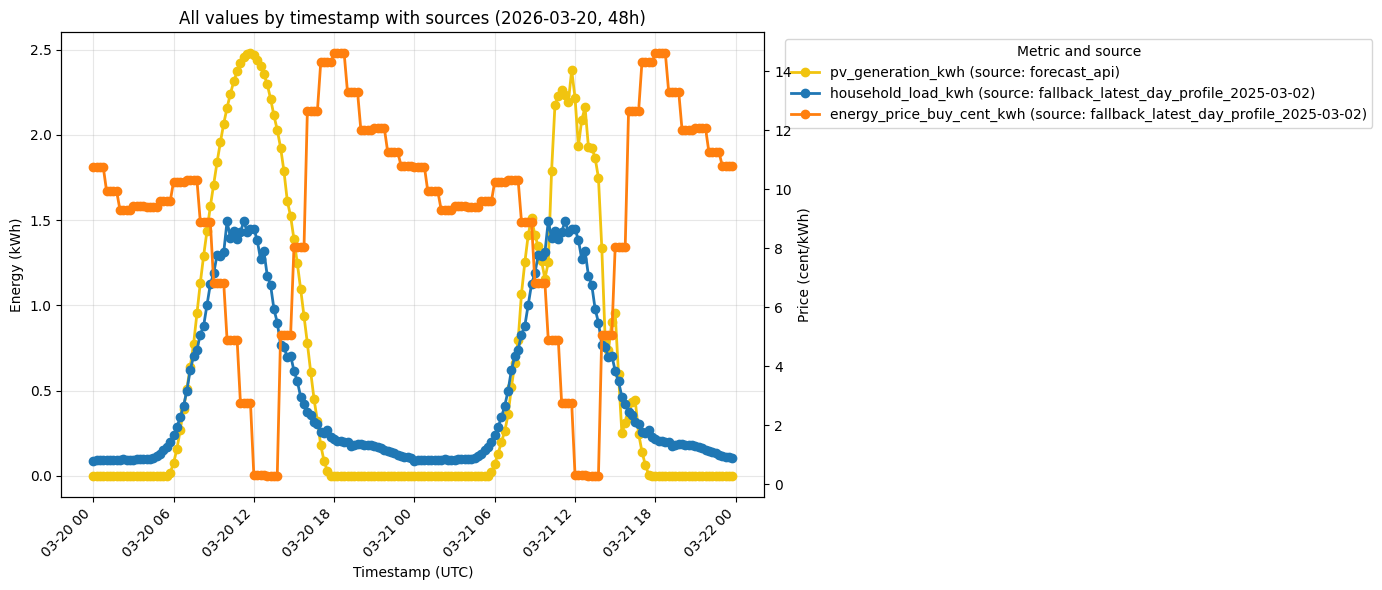

In [38]:
# Select and rename only the columns needed by downstream dispatch code.
df_new = df[["time", "predicted_kwh_x", "source_x", "price_cent_kwh", "source_y", "predicted_kwh_y", "household", "source"]]
df_new.columns = ["utc_timestamp", "pv_generation_kwh", "source_solar", "energy_price_buy_cent_kwh", "source_price", "household_load_kwh", "household", "source_load"]

# Persist files only when this run is allowed to refresh output (same day, >= 15 minutes).
if REFRESH_OCCURRED:
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_new.to_csv(OUTPUT_PATH, index=False)

    # Keep a tiny state file so later runs can decide refresh vs reuse.
    STATE_PATH.parent.mkdir(parents=True, exist_ok=True)
    state_payload = {
        "last_update_utc": NOW_UTC.isoformat(),
        "update_interval_minutes": 15,
        "start_day_utc": str(START_DAY),
        "rows": int(len(df_new)),
        "price_fallback_policy": "latest_available_day_profile",
    }
    STATE_PATH.write_text(json.dumps(state_payload, indent=2), encoding="utf-8")

    print(f"Saved refreshed 48h table to: {OUTPUT_PATH}")
    print(f"Updated refresh state in:     {STATE_PATH}")
else:
    print("No file update: same requested day and latest refresh is less than 15 minutes old.")
    print(f"Using existing table at: {OUTPUT_PATH}")

# Plot the final 48h table with dual y-axes (energy left, price right).
plot_df = df_new.copy()
plot_df["utc_timestamp"] = pd.to_datetime(plot_df["utc_timestamp"], utc=True)

def get_source_label(frame, source_col):
    source_values = frame[source_col].dropna().unique()
    return source_values[0] if len(source_values) > 0 else "unknown"

source_solar = get_source_label(plot_df, "source_solar")
source_price = get_source_label(plot_df, "source_price")
source_load = get_source_label(plot_df, "source_load")

fig, ax_left = plt.subplots(figsize=(14, 6))

line_solar = ax_left.plot(
    plot_df["utc_timestamp"],
    plot_df["pv_generation_kwh"],
    marker="o",
    linewidth=2,
    color="#f1c40f",
    label=f"pv_generation_kwh (source: {source_solar})",
)[0]

line_load = ax_left.plot(
    plot_df["utc_timestamp"],
    plot_df["household_load_kwh"],
    marker="o",
    linewidth=2,
    color="#1f77b4",
    label=f"household_load_kwh (source: {source_load})",
)[0]

ax_left.set_xlabel("Timestamp (UTC)")
ax_left.set_ylabel("Energy (kWh)")
ax_left.grid(alpha=0.3)

ax_right = ax_left.twinx()
line_price = ax_right.plot(
    plot_df["utc_timestamp"],
    plot_df["energy_price_buy_cent_kwh"],
    marker="o",
    linewidth=2,
    color="#ff7f0e",
    label=f"energy_price_buy_cent_kwh (source: {source_price})",
)[0]
ax_right.set_ylabel("Price (cent/kWh)")

lines = [line_solar, line_load, line_price]
labels = [line.get_label() for line in lines]
ax_left.legend(lines, labels, title="Metric and source", bbox_to_anchor=(1.02, 1), loc="upper left")

ax_left.set_title(f"All values by timestamp with sources ({date}, 48h)")
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()


## Notes

- Timestamps are handled in UTC to keep all sources aligned.
- The output schema is designed for downstream dispatch notebooks/scripts.
- Refresh state is stored in `data/.aggreg_table_state.json` to avoid unnecessary writes within one hour.